In [1]:
import numpy as np
import pyccl as ccl
import healpy as hp
from tqdm import tqdm
from astropy import units as u
from matplotlib import pyplot as plt

In [2]:
import sys, os
sys.path.append('/home/yshi/work/akra_series/utils/')
from gaussianfield import get_cl

sys.path.append('/home/yshi/work/akra_series/core/')

In [3]:
### Generate gamma1, gamma2 maps from convergence map using healpy
np.random.seed(12)
nside = 32 
lmax = int(nside*1.5)
nside_out = nside

from akra_full import sph_kappa2gamma
# ## skymap file name
# skymap_dir = "./akra_series/data_test/"
# skymap_file = skymap_dir + "skymap_lmax%d_nside%d.npz"%(lmax, nside)

l = np.arange(lmax)
cls = get_cl(ell=l)
cls[0] = 0.0
cls[1] = 0.0
alm_kappa = hp.synalm(cls)
kappa0 = hp.alm2map(alm_kappa, nside=nside_out)
gamma10, gamma20 = sph_kappa2gamma(kappa0, nside_out, lmax=lmax)

/home/yshi/work/akra_series/core/akra_full.py:18: RuntimeWarning: divide by zero encountered in true_divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)
/home/yshi/work/akra_series/core/akra_full.py:18: RuntimeWarning: invalid value encountered in true_divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)


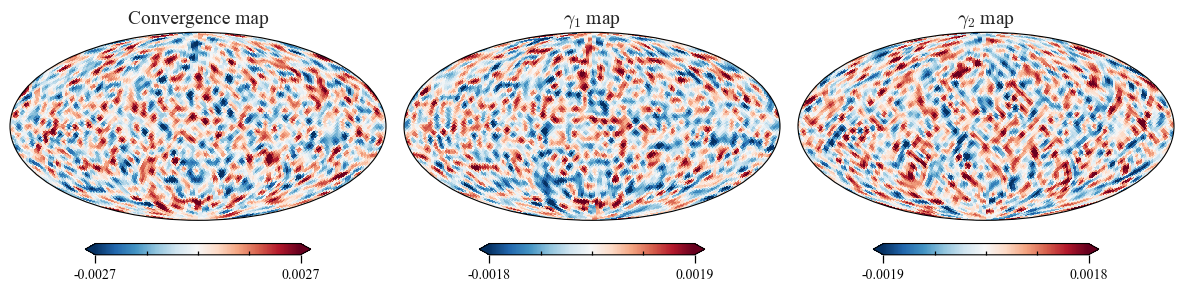

In [15]:
from hpplot import mollview
plt.figure(figsize=(12,5))
mollview(kappa0, sub=131, title='Convergence map')
mollview(gamma10, sub=132, title='$\gamma_1$ map')
mollview(gamma20, sub=133, title='$\gamma_2$ map')

/home/yshi/.conda/envs/nb/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in power
  """
/home/yshi/.local/lib/python3.7/site-packages/healpy/visufunc.py:332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()


mask percent: 0.4196


/home/yshi/.conda/envs/nb/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


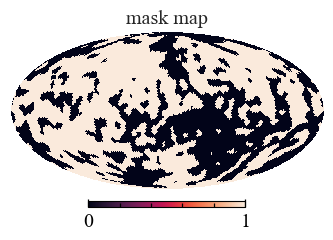

In [5]:
### Generate mask map 
lmax_mask = lmax-10
l = np.arange(lmax_mask)
cl_sel = np.ones_like(l) 
cl_sel = l**-1.5
cl_sel[0] = 0
# plt.semilogx(cl_sel)
sel = hp.synfast(cl_sel, nside_out)
sel = np.tanh(sel/sel.std()/3.0) + 1.0
sel = sel/sel.max()
mask = np.zeros_like(sel)
th = 0.5
mask[sel>th] = 1
mask[sel<=th] = 0
hp.mollview(mask, sub=(2,2,1), title='mask map')
mask_percent = 1-np.sum(mask==1)/len(mask)
print("mask percent: %.4f"%(mask_percent))

In [6]:
### Generate observed shear maps
gamma1_obs = gamma10 * mask
gamma2_obs = gamma20 * mask

########## Note: Pay attention there may be -1*gamma1/gamma2 difference in different coordinate conventions ##########

### AKRA reconstruction

In [7]:
from akra_full import KappaRec_sphere
kappa_rec = KappaRec_sphere(gamma1_obs, gamma2_obs, mask, lmax=lmax, choSolve=True)
kappa_rec.sphere_AKRA(nosh=True) ## nosh=True means ((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5 factor is included in the reconstruction

Observed yy shape:  (2, 2401)
Calculating A^T A...


100%|██████████| 1225/1225 [03:30<00:00,  5.83it/s]


Time used:  210.30704998970032 s
The shape of A is:  (4802, 2401)
Calculating the inverse of the psf: ... 

psf dtype:  complex64
 .   Calculating the cholesky decomposition of the psf ... 

    Time taken for cholesky decomposition: 0.86 s
1225


100%|██████████| 1225/1225 [00:00<00:00, 37003.32it/s]
/home/yshi/work/akra_series/core/akra_full.py:272: RuntimeWarning: divide by zero encountered in true_divide
  alm_kappar = 1*alm_kappar*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/akra_series/core/akra_full.py:272: RuntimeWarning: invalid value encountered in multiply
  alm_kappar = 1*alm_kappar*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/akra_series/core/akra_full.py:273: RuntimeWarning: divide by zero encountered in true_divide
  alm_kappai = 1*alm_kappai*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/akra_series/core/akra_full.py:273: RuntimeWarning: invalid value encountered in multiply
  alm_kappai = 1*alm_kappai*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5


In [8]:
akra_map = kappa_rec.kappa_akra

In [9]:
### KS results
kappa_rec.sphere_KS(nosh=True) ## nosh=True means ((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5 factor is included in the reconstruction
ks_map = kappa_rec.kappa_ks

/home/yshi/work/akra_series/core/sphere_ks.py:137: RuntimeWarning: divide by zero encountered in true_divide
  alm_E = 1.*alm_E*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5
/home/yshi/work/akra_series/core/sphere_ks.py:137: RuntimeWarning: invalid value encountered in multiply
  alm_E = 1.*alm_E*((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5


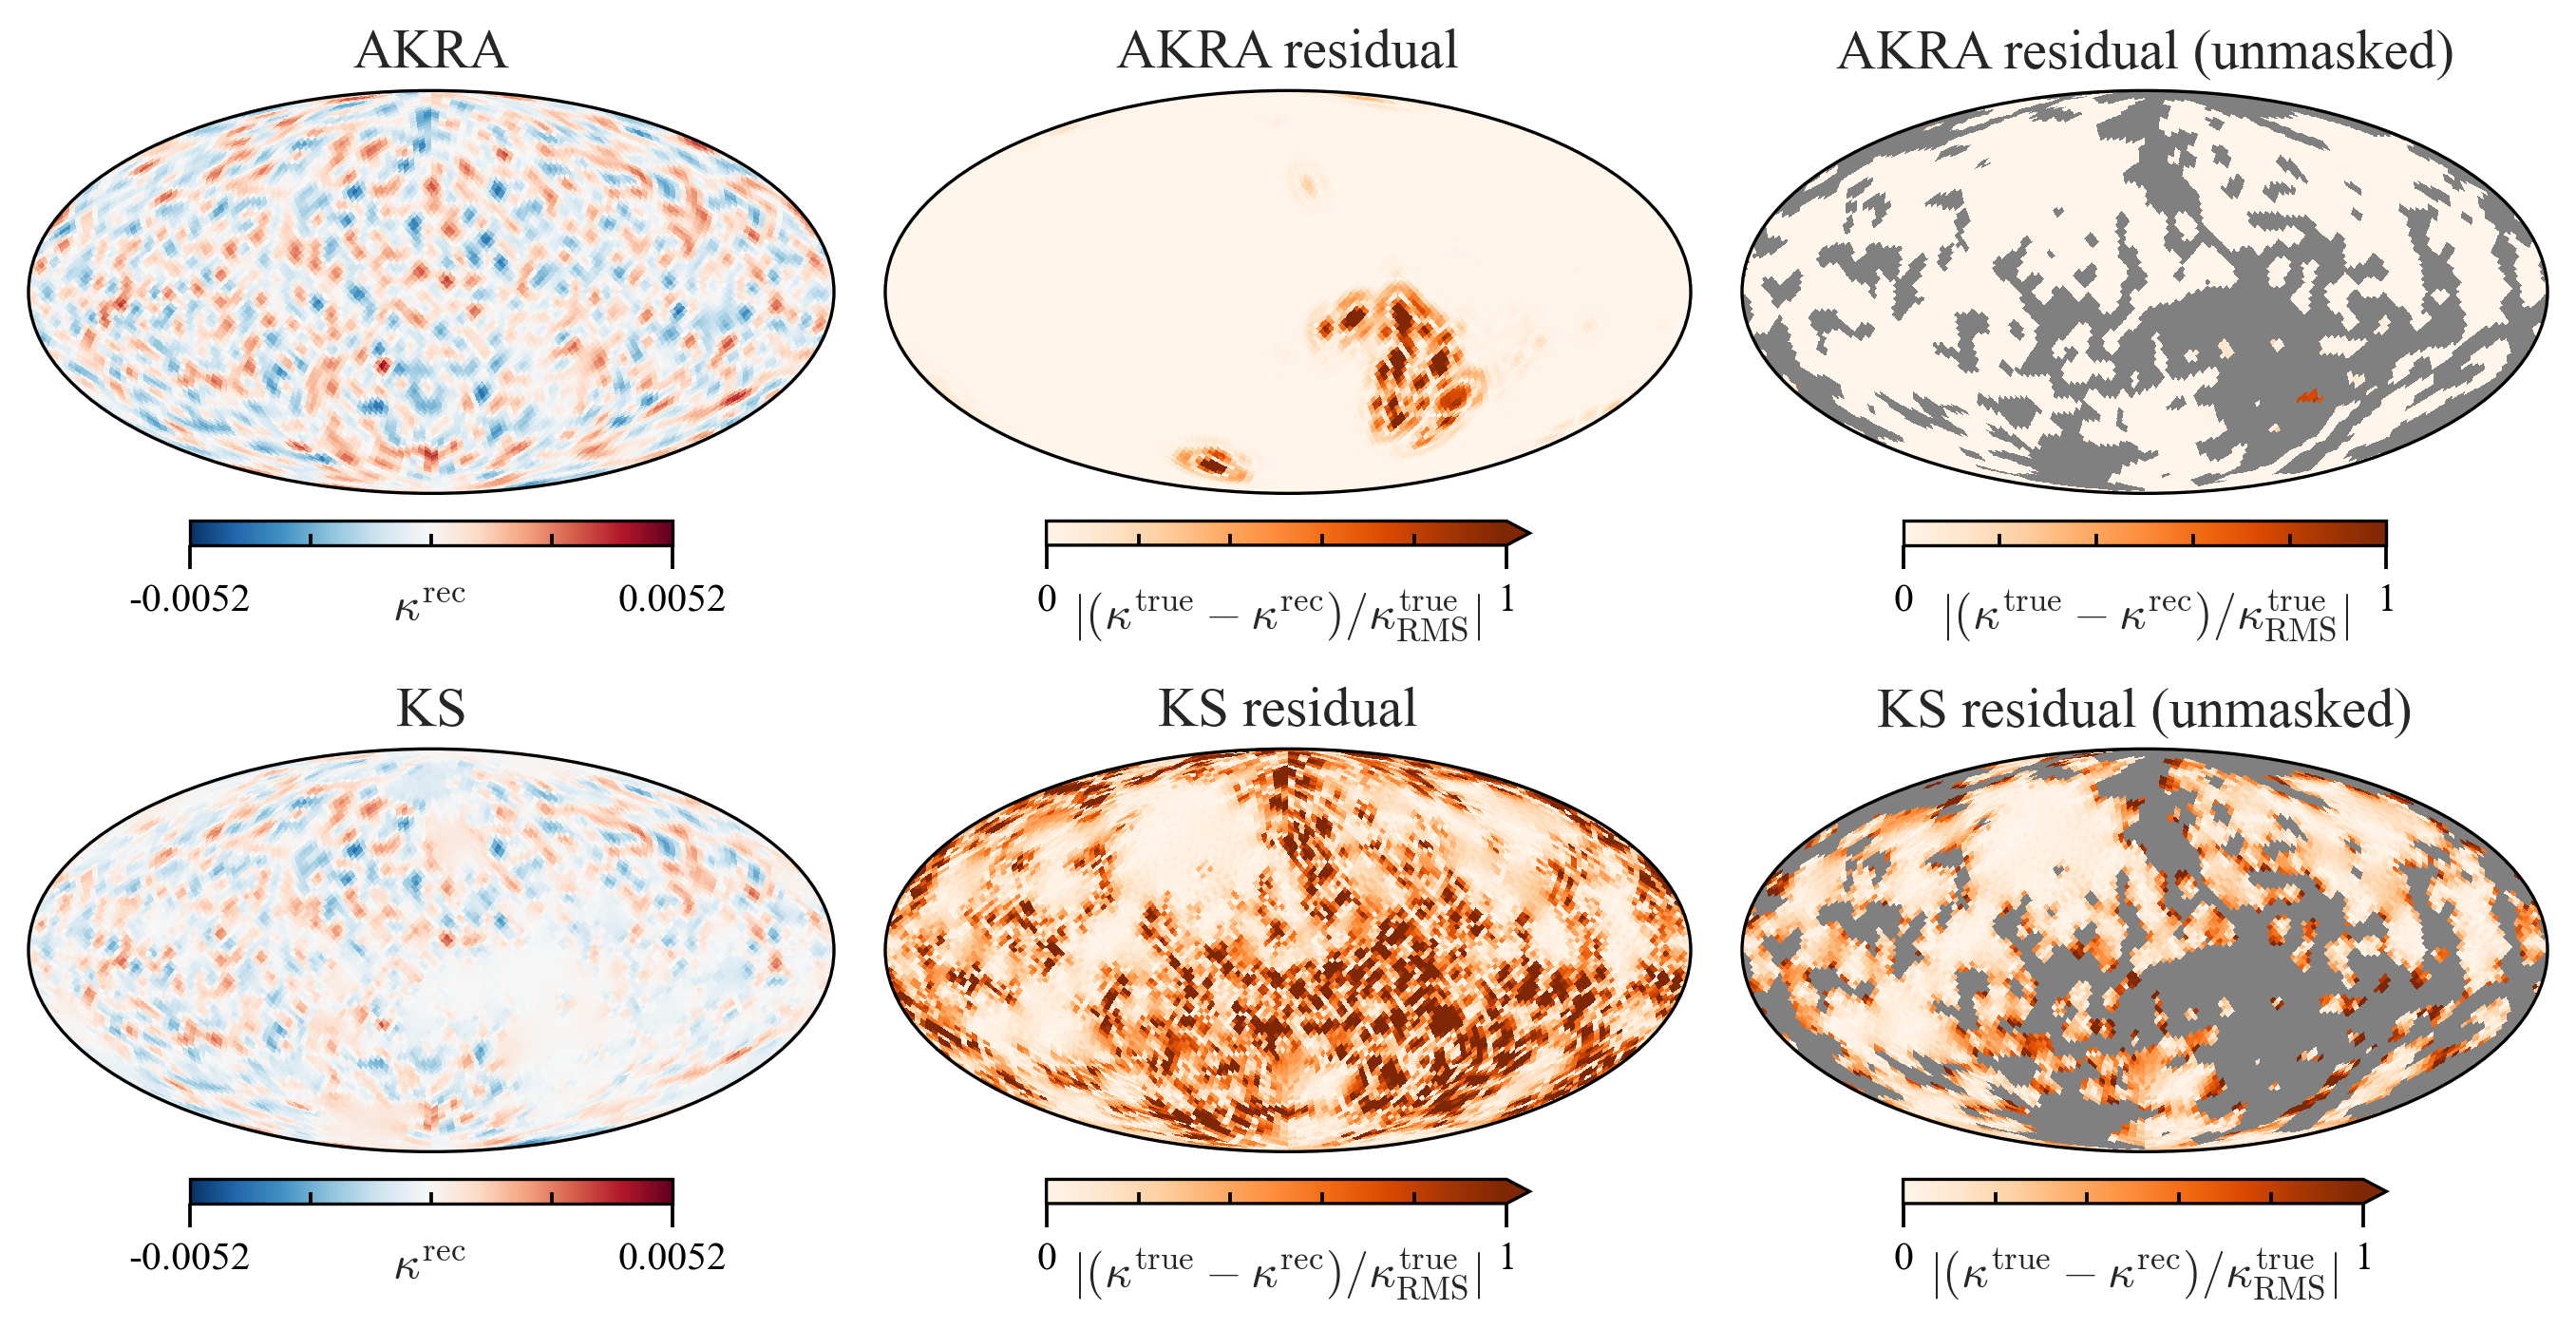

In [16]:
plt.figure(figsize=(9.2,4.8), dpi=300)
vmin = -0.0052
vmax = 0.0052
mollview(akra_map, sub=231, title="AKRA", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(akra_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=232, vmin=0, vmax=1, title="AKRA residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(akra_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=233, vmin=0, vmax=1, title="AKRA residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)

mollview(ks_map, sub=234, title="KS", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(ks_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=235, vmin=0, vmax=1, title="KS residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(ks_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=236, vmin=0, vmax=1, title="KS residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)
# plt.subplots_adjust(hspace=0.01)
# plt.savefig(figDir + "random_g1g2Mask-results.pdf", bbox_inches='tight', transparent=True)
plt.show()